In [1]:
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge
import geopandas as gpd
from shapely.geometry import Point, Polygon
import math
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from path_config import dl_data, bs_data

In [2]:
dl = pd.read_excel(dl_data, sheet_name="Series Formatted Data")

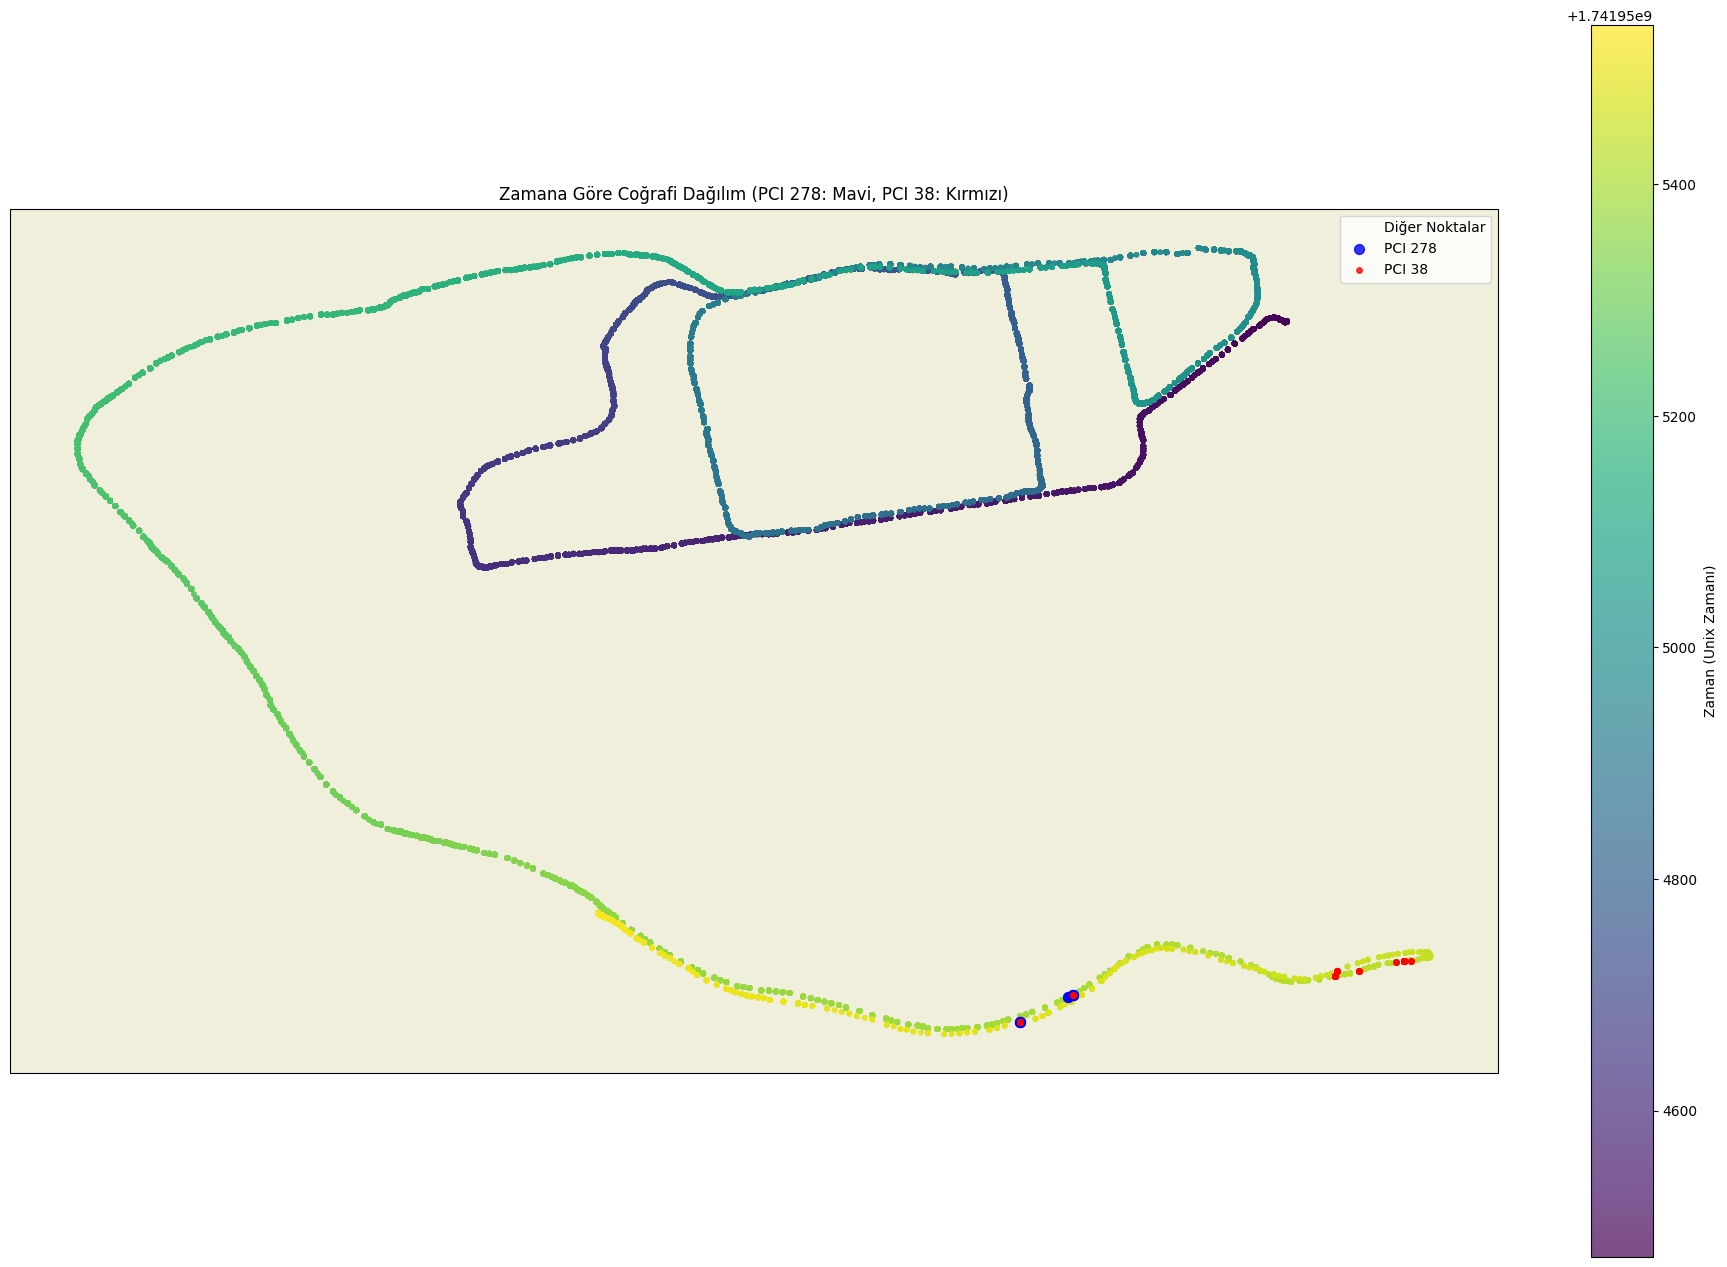

In [3]:
# Zamanı normalize ederek renk skalasına dönüştür
time_numeric = pd.to_datetime(dl["Time"]).astype(int) / 10**9

# Harita oluştur
fig = plt.figure(figsize=(24, 16))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)

# Ana scatter plot (zaman skalalı renkler)
sc = ax.scatter(
    dl["Longitude"],
    dl["Latitude"],
    c=time_numeric,
    cmap="viridis",
    s=10,
    alpha=0.7,
    label="Diğer Noktalar"
)

# PCI değeri 278 olanları filtrele ve mavi renkte göster
mask_278 = dl["NR_UE_PCI_0"] == 278
ax.scatter(
    dl[mask_278]["Longitude"],
    dl[mask_278]["Latitude"],
    color="blue",
    s=50,
    alpha=0.8,
    label="PCI 278"
)

# PCI değeri 38 olanları filtrele ve kırmızı renkte göster
mask_38 = dl["NR_UE_PCI_0"] == 38
ax.scatter(
    dl[mask_38]["Longitude"],
    dl[mask_38]["Latitude"],
    color="red",
    s=15,
    alpha=0.8,
    label="PCI 38"
)

plt.colorbar(sc, label="Zaman (Unix Zamanı)")
ax.set_title("Zamana Göre Coğrafi Dağılım (PCI 278: Mavi, PCI 38: Kırmızı)")
ax.legend()

plt.show()


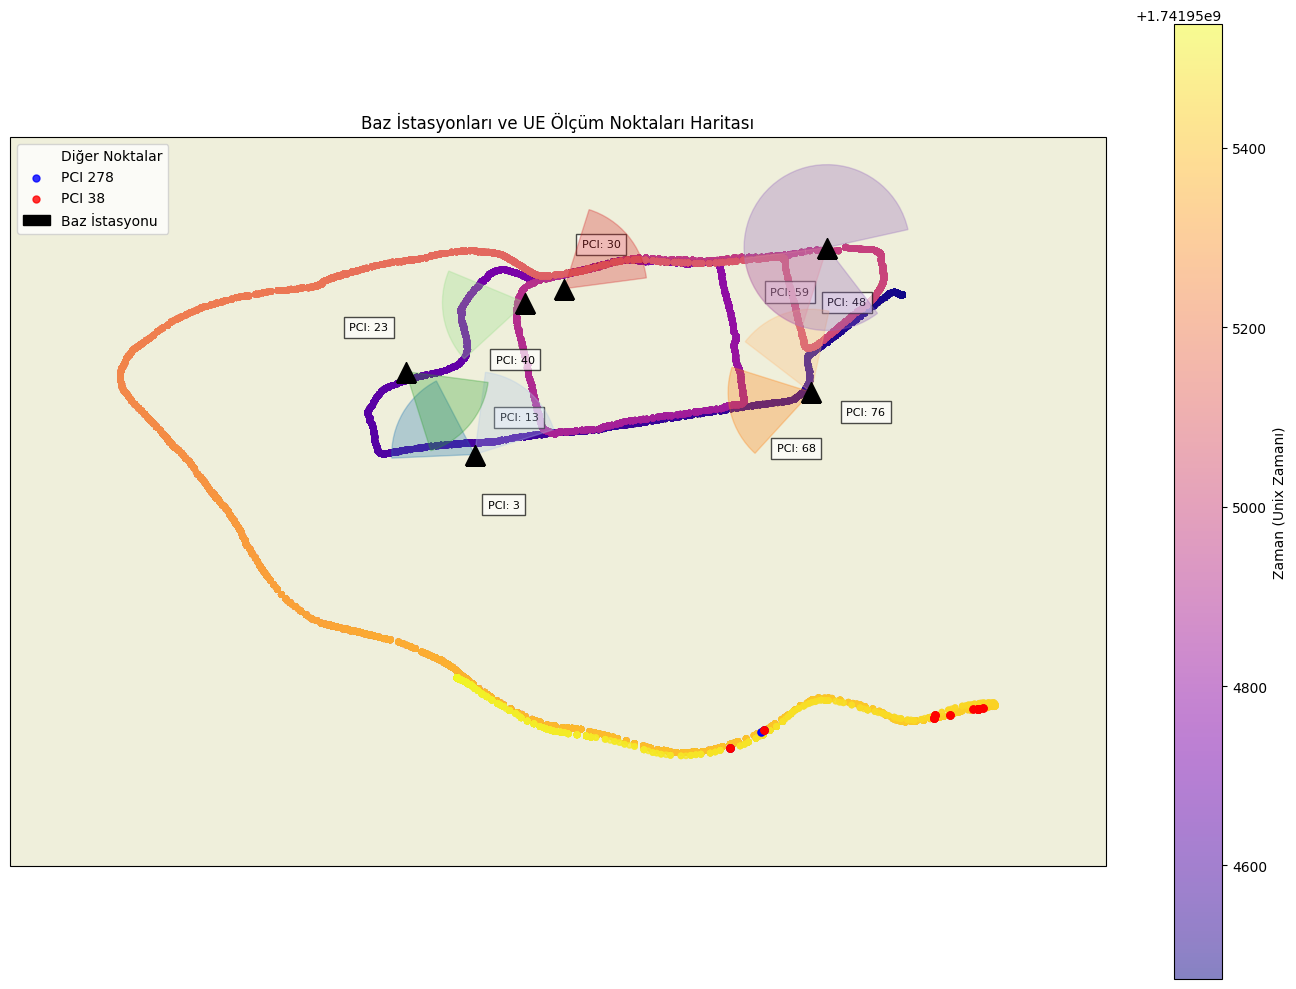

In [4]:

bs_df = pd.read_excel(bs_data, sheet_name="Hücre tablosu")

# Zamanı normalize ederek renk skalasına dönüştür
time_numeric = pd.to_datetime(dl["Time"]).astype(int) / 10**9

# Harita oluştur
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)

# Haritayı ölçeklendir ve baz istasyonları etrafına odakla
buffer = 0.002  # Yaklaşık 200 metre buffer
min_lon = min(bs_df["Longitude"].min(), dl["Longitude"].min()) - buffer
max_lon = max(bs_df["Longitude"].max(), dl["Longitude"].max()) + buffer
min_lat = min(bs_df["Latitude"].min(), dl["Latitude"].min()) - buffer
max_lat = max(bs_df["Latitude"].max(), dl["Latitude"].max()) + buffer

ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Ana scatter plot (zaman skalalı renkler)
sc = ax.scatter(
    dl["Longitude"],
    dl["Latitude"],
    c=time_numeric,
    cmap="plasma",
    s=15,
    alpha=0.5,
    label="Diğer Noktalar"
)

# PCI değeri 278 olanları filtrele ve mavi renkte göster
mask_278 = dl["NR_UE_PCI_0"] == 278
ax.scatter(
    dl[mask_278]["Longitude"],
    dl[mask_278]["Latitude"],
    color="blue",
    s=25,
    alpha=0.8,
    label="PCI 278"
)

# PCI değeri 38 olanları filtrele ve kırmızı renkte göster
mask_38 = dl["NR_UE_PCI_0"] == 38
ax.scatter(
    dl[mask_38]["Longitude"],
    dl[mask_38]["Latitude"],
    color="red",
    s=25,
    alpha=0.8,
    label="PCI 38"
)

# PCI renk haritası oluştur - baz istasyonlarını temsil etmek için
pci_cmap = plt.cm.tab20(np.linspace(0, 1, 20))
pci_colors = dict()

# Baz istasyonlarını ekle
station_groups = bs_df.groupby(["Latitude", "Longitude"])
for (lat, lon), group in station_groups:
    # Baz istasyonu konumunu işaretle
    ax.plot(lon, lat, 'k^', markersize=14, markeredgecolor='black', zorder=10)
    
    # Her sektör için kapsama alanını çiz
    for _, row in group.iterrows():
        azimuth = row["Azimuth [°]"]
        beamwidth = row["Horizontal Beamwidth [°]"]
        pci = row["PCI "]
        
        # Her PCI için tutarlı renk ataması yap
        if pci not in pci_colors:
            pci_colors[pci] = pci_cmap[len(pci_colors) % 20]
        
        # Kapsama alanını dilim (wedge) olarak göster
        # Azimuth açısı, beamwidth ve kapsama mesafesi
        start_angle = (azimuth - beamwidth/2) % 360
        end_angle = (azimuth + beamwidth/2) % 360
        
        # Açıları matematik açısından (saat yönünün tersi) coğrafi açıya (kuzeyden saat yönünde) dönüştür
        start_angle = (90 - start_angle) % 360
        end_angle = (90 - end_angle) % 360
        if start_angle > end_angle:
            start_angle, end_angle = end_angle, start_angle
            
        # Kapsama mesafesi - güç ve yükseklik baz alınarak basit bir tahmin
        # Gerçek kapsama alanı için daha karmaşık propagasyon modelleri kullanılmalıdır
        coverage_radius = 0.0015  # Yaklaşık 150 metre
        
        wedge = Wedge((lon, lat), coverage_radius, start_angle, end_angle, 
                     alpha=0.3, color=pci_colors[pci], zorder=5)
        ax.add_patch(wedge)
        
        # PCI değerini göster
        # Yön vektörünün ortasında PCI değerini göster
        middle_angle_rad = np.radians((start_angle + end_angle) / 2)
        # Kartezyen koordinatlara dönüştür (matematik açısı olduğundan sin ve cos yer değiştirir)
        dx = np.sin(middle_angle_rad) * coverage_radius * 0.7
        dy = np.cos(middle_angle_rad) * coverage_radius * 0.7
        ax.text(lon + dx, lat + dy, f"PCI: {int(pci)}", fontsize=8, 
                ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7))

# Renk ölçeği ekle
cbar = plt.colorbar(sc, label="Zaman (Unix Zamanı)")

ax.set_title("Baz İstasyonları ve UE Ölçüm Noktaları Haritası")

# Lejant oluştur
handles, labels = ax.get_legend_handles_labels()

# Baz istasyonu için lejant ekle
station_marker = mpatches.Patch(color='black', label='Baz İstasyonu')
handles.append(station_marker)
labels.append('Baz İstasyonu')

ax.legend(handles=handles, labels=labels, loc='upper left')

plt.tight_layout()
plt.show()

In [5]:
# 1. Baz İstasyonları için GeoDataFrame oluştur
geometry = [Point(xy) for xy in zip(bs_df["Longitude"], bs_df["Latitude"])]
base_stations_gdf = gpd.GeoDataFrame(bs_df, geometry=geometry, crs="EPSG:4326")

# Baz istasyonlarını grupla (aynı konumdaki istasyonları birleştir)
base_stations_grouped = base_stations_gdf.dissolve(by=["Latitude", "Longitude"]).reset_index()
base_stations_grouped["type"] = "base_station"

# 2. Hücre sektörleri için GeoDataFrame oluştur
sectors_list = []

for _, row in bs_df.iterrows():
    lat = row["Latitude"]
    lon = row["Longitude"]
    azimuth = row["Azimuth [°]"]
    beamwidth = row["Horizontal Beamwidth [°]"]
    pci = row["PCI "]
    cell_name = row["Cell Name"]
    sector = row["Sector "]
    kabinet = row["Kabinet"]
    height = row["Height [m]"]
    power = row["Power [W]"]
    
    # Kapsama mesafesini güç ve yüksliğe göre ayarla (basit bir model)
    # Gerçek uygulamada daha karmaşık propagasyon modelleri kullanılır
    coverage_distance = 1000  # metre
    coverage_distance = coverage_distance * (power/200)**0.5 * (height/10)**0.3
    
    # Dilim (wedge) oluştur
    start_angle = (azimuth - beamwidth/2) % 360
    end_angle = (azimuth + beamwidth/2) % 360
    
    # Açıları radian'a çevir
    start_angle_rad = math.radians(start_angle)
    end_angle_rad = math.radians(end_angle)
    
    # Büyük bir çokgen oluşturmak için açıları küçük adımlara böl
    num_points = 20
    if start_angle > end_angle:
        angles = np.linspace(start_angle_rad, end_angle_rad + 2*np.pi, num_points)
    else:
        angles = np.linspace(start_angle_rad, end_angle_rad, num_points)
    
    # WGS84 (EPSG:4326) koordinat sisteminde açısal mesafeyi metreye çevir
    # 1 derece yaklaşık 111 km (ekvator)
    # Boylam için enlem faktörü: cos(lat * pi/180)
    lat_factor = 111000  # 1 derece enlem yaklaşık 111 km
    lon_factor = 111000 * math.cos(math.radians(lat))  # Boylam faktörü
    
    # Merkez nokta
    source_point = Point(lon, lat)
    
    # Dilim çokgenini oluştur
    # Başlangıç noktası: baz istasyonu konumu
    polygon_points = [source_point]
    
    # Dilim kenarları boyunca noktalar
    for angle in angles:
        # Açıdan x ve y bileşenlerini hesapla (kuzeyden başlayarak saat yönünde)
        dx = math.sin(angle) * coverage_distance / lon_factor
        dy = math.cos(angle) * coverage_distance / lat_factor
        
        # Yeni koordinatlar
        new_lon = lon + dx
        new_lat = lat + dy
        
        polygon_points.append(Point(new_lon, new_lat))
    
    # Çokgeni kapat
    polygon_points.append(source_point)
    
    # Koordinatları çokgene dönüştür
    coords = [(p.x, p.y) for p in polygon_points]
    sector_polygon = Polygon(coords)
    
    # Sektör verilerini ekle
    sectors_list.append({
        "geometry": sector_polygon,
        "Kabinet": kabinet,
        "Sector": sector,
        "CellName": cell_name,
        "PCI": pci,
        "Azimuth": azimuth,
        "Beamwidth": beamwidth,
        "Height": height,
        "Power": power,
        "type": "sector"
    })

# Sektörler için GeoDataFrame oluştur
sectors_gdf = gpd.GeoDataFrame(sectors_list, crs="EPSG:4326")

# 3. UE noktaları için (varsa) GeoDataFrame oluştur
# Burada dl DataFrame'inin var olduğunu ve gerekli sütunları içerdiğini varsayıyoruz
# Eğer dl DataFrame'i tanımlı değilse, bu kısmı atlayabilirsiniz
try:
    geometry = [Point(xy) for xy in zip(dl["Longitude"], dl["Latitude"])]
    ue_gdf = gpd.GeoDataFrame(dl, geometry=geometry, crs="EPSG:4326")
    
    # PCI 38 ve 278 için filtreleme
    ue_pci_38_gdf = ue_gdf[ue_gdf["NR_UE_PCI_0"] == 38].copy()
    ue_pci_38_gdf["PCIType"] = "PCI 38"
    
    ue_pci_278_gdf = ue_gdf[ue_gdf["NR_UE_PCI_0"] == 278].copy()
    ue_pci_278_gdf["PCIType"] = "PCI 278"
    
    ue_other_gdf = ue_gdf[~ue_gdf["NR_UE_PCI_0"].isin([38, 278])].copy()
    ue_other_gdf["PCIType"] = "Other PCI"
    
    # Tüm UE verilerini tek bir GeoDataFrame'de birleştir
    ue_combined_gdf = pd.concat([ue_pci_38_gdf, ue_pci_278_gdf, ue_other_gdf])
    ue_combined_gdf["type"] = "ue_point"
    
    has_ue_data = True
except NameError:
    print("UE veri çerçevesi (dl) bulunamadı, sadece baz istasyonları ve sektörler kaydedilecek.")
    has_ue_data = False

# 4. Tüm katmanları tek bir GeoPackage'a kaydet (QGIS'te kullanım için idealdir)
if has_ue_data:
    # Tüm GeoDataFrame'leri bir liste içinde birleştir
    all_layers = {
        'base_stations': base_stations_gdf,
        'sectors': sectors_gdf,
        'ue_points': ue_combined_gdf
    }
else:
    all_layers = {
        'base_stations': base_stations_gdf,
        'sectors': sectors_gdf
    }

# GeoPackage'a kaydet
for layer_name, gdf in all_layers.items():
    gdf.to_file("telecom_network.gpkg", layer=layer_name, driver="GPKG")


print("GeoPackage dosyası: telecom_network.gpkg")

GeoPackage dosyası: telecom_network.gpkg


In [6]:
import folium
import math
import pandas as pd

# Örnek baz istasyonu verilerini içeren DataFrame (daha önce tanımlanan veriler)
data = {
    'Kabinet': ['WITUFERG', 'WITUFERG', 'WITUFERG', 'WITUFESG', 'WITUFESG', 'WITUFESG', 'WITUPAG', 'WITUPAG', 'WITUPAG'],
    'Sector': ['AAS-S1CB', 'AAS-S2CB', 'AAS-S3CB', 'AAS-S1CB', 'AAS-S2CB', 'AAS-S3CB', 'AAS-S1CB', 'AAS-S2CB', 'AAS-S3CB'],
    'Cell Name': ['ITUCELL4BG', 'ITUCELL5BG', 'ITUCELL7BG', 'ITUCELL6BG', 'ITUCELL8BG', 'ITUCELL9BG', 'ITUCELL1BG', 'ITUCELL2BG', 'ITUCELL3BG'],
    'Latitude': [41.1073413, 41.1070873, 41.1080861, 41.1080861, 41.1054694, 41.1054694, 41.1043417, 41.1043417, 41.1058417],
    'Longitude': [29.0233668, 29.0226646, 29.0281222, 29.0281222, 29.0278333, 29.0278333, 29.0217472, 29.0217472, 29.0205028],
    'Azimuth': [50, 260, 230, 110, 255, 340, 300, 40, 130],
    'Horizontal Beamwidth': [65, 65, 65, 65, 65, 65, 65, 65, 65],
    'Vertical Beamwidth': [10, 10, 10, 10, 9.5, 9.5, 10, 10, 10],
    'Height': [10, 10, 6, 6, 18, 18, 6, 6, 6],
    'MIMO': ['64T64R', '64T64R', '64T64R', '64T64R', '32T32R', '32T32R', '64T64R', '64T64R', '64T64R'],
    'PCI': [30, 40, 59, 48, 68, 76, 3, 13, 23],
    'rachroot': [26, 126, 42, 69, 132, 75, 30, 130, 93],
    'Power_W': [200]*9,
    'Ssbpower_dBm': [17.91]*9
}

basestations = pd.DataFrame(data)



# Her iki veri setini de tek bir harita üzerinde göstermek için, haritanın merkezini tüm baz istasyonu ve dl noktalarının ortalamasını alarak belirleyelim.
all_lats = pd.concat([basestations['Latitude'], dl['Latitude']])
all_lons = pd.concat([basestations['Longitude'], dl['Longitude']])
center_lat = all_lats.mean()
center_lon = all_lons.mean()

# Folium haritası oluşturuluyor.
m = folium.Map(location=[center_lat, center_lon], zoom_start=15)

# Sektör (kapsama alanı) poligonlarını oluşturacak fonksiyon
def create_sector_polygon(lat, lon, azimuth, beamwidth, radius, num_points=30):
    """
    Belirli bir koordinattan, azimut ve beamwidth'e göre sektör poligonu oluşturur.
    :param lat: Merkez noktasının enlemi
    :param lon: Merkez noktasının boylamı
    :param azimuth: Merkez yön (derece)
    :param beamwidth: Yatay beamwidth (derece)
    :param radius: Kapsama yarıçapı (metre)
    :param num_points: Poligon oluşturmak için kullanılacak nokta sayısı
    :return: (lat, lon) listesi içeren nokta listesi
    """
    start_angle = azimuth - beamwidth / 2
    end_angle = azimuth + beamwidth / 2
    angle_step = (end_angle - start_angle) / num_points
    
    points = []
    # Merkez nokta (baz istasyonu konumu)
    points.append((lat, lon))
    
    for i in range(num_points + 1):
        angle = math.radians(start_angle + i * angle_step)
        # Yaklaşık: 1° enlem farkı ≈ 111 km
        delta_lat = (radius * math.cos(angle)) / 111000  # metre -> enlem farkı
        # Boylam farkı: enleme bağlı olarak 1° ≈ 111 km * cos(lat)
        delta_lon = (radius * math.sin(angle)) / (111000 * math.cos(math.radians(lat)))
        points.append((lat + delta_lat, lon + delta_lon))
    
    # Poligonun kapanması için başlangıç noktasını ekle
    points.append(points[0])
    return points

# Baz istasyonu verileri için sektör poligonlarını ve marker'ları ekleyelim.
default_radius = 1000  # Örnek yarıçap: 1000 metre



In [7]:
import folium

# Harita merkezi (önceden hesapladığımız gibi)
center_lat = pd.concat([basestations['Latitude'], dl['Latitude']]).mean()
center_lon = pd.concat([basestations['Longitude'], dl['Longitude']]).mean()

# Harita objesini oluştur
m = folium.Map(location=[center_lat, center_lon], zoom_start=14)

# Baz istasyonlarının kapsama alanlarını ve markerlarını ekleyelim (önceki kodlarınızla aynı)
for idx, row in basestations.iterrows():
    sector_points = create_sector_polygon(row['Latitude'], row['Longitude'],
                                          row['Azimuth'],
                                          row['Horizontal Beamwidth'],
                                          default_radius)
    folium.Polygon(
        locations=sector_points,
        color='blue',
        fill=True,
        fill_color='blue',
        fill_opacity=0.3,
        popup=f"{row['PCI']} ({row['Sector']})"
    ).add_to(m)
    
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"{row['Cell Name']} - {row['Kabinet']}",
        icon=folium.Icon(color='red', icon='signal')
    ).add_to(m)

# 🔵 DL noktalarını çizgi olarak ekleyelim
# Sıralı şekilde birleştir (önceden sıralı olduğunu varsayalım, değilse sıraya göre sort edilebilir)
dl_line = dl[['Latitude', 'Longitude']].dropna().values.tolist()

# PolyLine olarak ekle
folium.PolyLine(
    locations=dl_line,
    color='green',
    weight=5,
    opacity=0.8,
    popup='DL route'
).add_to(m)

# Haritayı kaydet
m.save("baz_istasyonlari_ve_dl_cizgi.html")
print("Harita 'baz_istasyonlari_ve_dl_cizgi.html' olarak kaydedildi.")


Harita 'baz_istasyonlari_ve_dl_cizgi.html' olarak kaydedildi.


In [12]:
def oklidian_distance(lat1, lon1, lat2, lon2):
    """
    İki nokta arasındaki Öklidyen mesafeyi hesaplar.
    :param lat1: İlk noktanın enlemi
    :param lon1: İlk noktanın boylamı
    :param lat2: İkinci noktanın enlemi
    :param lon2: İkinci noktanın boylamı
    :return: Mesafe (metre cinsinden)
    """
    return math.sqrt((lat1 - lat2) ** 2 + (lon1 - lon2) ** 2) * 111  # Yaklaşık 111 km = 1° enlem/boylam farkı

In [13]:
def calculate_distance(row, pci_col):
    """Dinamik PCI kolon adı ile mesafe hesaplama"""
    try:
        current_pci = row[pci_col]
        if pd.isna(current_pci):
            return np.nan
            
        # PCI eşleşmesini bul
        pci_mask = bs_df["PCI "] == current_pci
        
        if not pci_mask.any():
            return np.nan
            
        # BS koordinatlarını al
        bs_lat = bs_df.loc[pci_mask, "Latitude"].iloc[0]
        bs_lon = bs_df.loc[pci_mask, "Longitude"].iloc[0]
        
        return oklidian_distance(row["Latitude"], row["Longitude"], bs_lat, bs_lon)
        
    except (IndexError, KeyError, TypeError):
        return np.nan

# Tüm PCI kolonlarını listele
pci_columns = [
    "NR_UE_PCI_0",
    "NR_UE_Nbr_PCI_0",
    "NR_UE_Nbr_PCI_1", 
    "NR_UE_Nbr_PCI_2",
    "NR_UE_Nbr_PCI_3",
    "NR_UE_Nbr_PCI_4"
]

# Her PCI kolonu için mesafe hesapla
for col in pci_columns:
    new_col_name = f"distance_to_{col.lower()[6:]}"
    dl[new_col_name] = dl.apply(lambda row: calculate_distance(row, col), axis=1)

In [14]:
bs_df["max_coverage"] = bs_df["PCI "].apply(lambda x: max(dl[dl["NR_UE_PCI_0"] == x]["distance_to_pci_0"].max(), dl[dl["NR_UE_Nbr_PCI_0"] == x]["distance_to_nbr_pci_0"].max(), dl[dl["NR_UE_Nbr_PCI_1"] == x]["distance_to_nbr_pci_1"].max(), dl[dl["NR_UE_Nbr_PCI_2"] == x]["distance_to_nbr_pci_2"].max(), dl[dl["NR_UE_Nbr_PCI_3"] == x]["distance_to_nbr_pci_3"].max(), dl[dl["NR_UE_Nbr_PCI_4"] == x]["distance_to_nbr_pci_4"].max()))

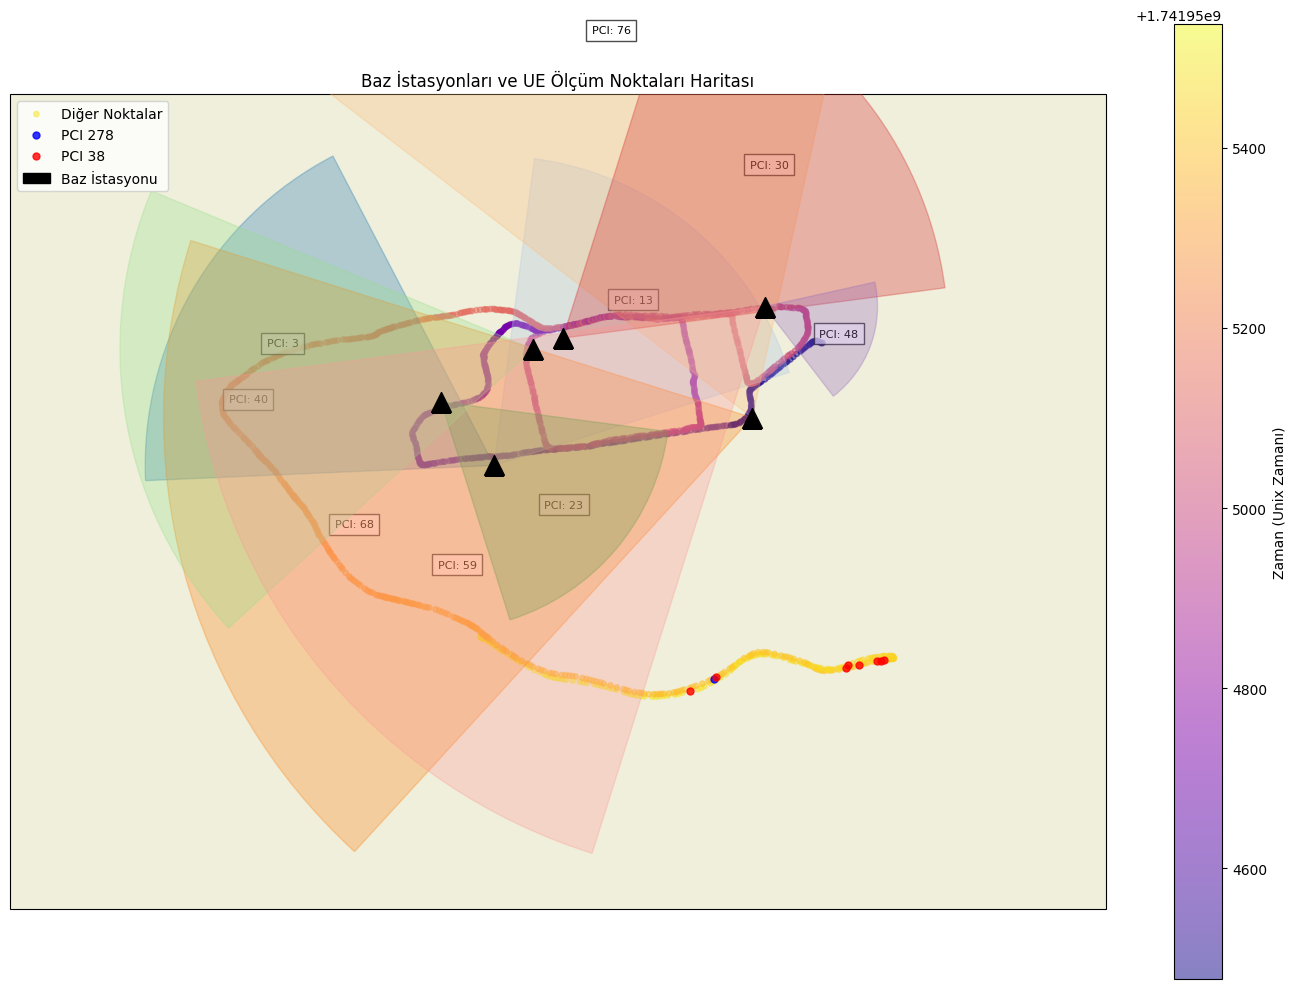

In [15]:
time_numeric = pd.to_datetime(dl["Time"]).astype(int) / 10**9

# Harita oluştur
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)

# Haritayı ölçeklendir ve baz istasyonları etrafına odakla
buffer = 0.005  # Yaklaşık 500 metre buffer
min_lon = min(bs_df["Longitude"].min(), dl["Longitude"].min()) - buffer
max_lon = max(bs_df["Longitude"].max(), dl["Longitude"].max()) + buffer
min_lat = min(bs_df["Latitude"].min(), dl["Latitude"].min()) - buffer
max_lat = max(bs_df["Latitude"].max(), dl["Latitude"].max()) + buffer

ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

# Ana scatter plot (zaman skalalı renkler)
sc = ax.scatter(
    dl["Longitude"],
    dl["Latitude"],
    c=time_numeric,
    cmap="plasma",
    s=15,
    alpha=0.5,
    label="Diğer Noktalar"
)

# PCI değeri 278 olanları filtrele ve mavi renkte göster
mask_278 = dl["NR_UE_PCI_0"] == 278
ax.scatter(
    dl[mask_278]["Longitude"],
    dl[mask_278]["Latitude"],
    color="blue",
    s=25,
    alpha=0.8,
    label="PCI 278"
)

# PCI değeri 38 olanları filtrele ve kırmızı renkte göster
mask_38 = dl["NR_UE_PCI_0"] == 38
ax.scatter(
    dl[mask_38]["Longitude"],
    dl[mask_38]["Latitude"],
    color="red",
    s=25,
    alpha=0.8,
    label="PCI 38"
)



# PCI renk haritası oluştur - baz istasyonlarını temsil etmek için
pci_cmap = plt.cm.tab20(np.linspace(0, 1, 20))
pci_colors = dict()

# Baz istasyonlarını ekle
station_groups = bs_df.groupby(["Latitude", "Longitude"])
for (lat, lon), group in station_groups:
    # Baz istasyonu konumunu işaretle
    ax.plot(lon, lat, 'k^', markersize=14, markeredgecolor='black', zorder=10)
    
    # Her sektör için kapsama alanını çiz
    for _, row in group.iterrows():
        azimuth = row["Azimuth [°]"]
        beamwidth = row["Horizontal Beamwidth [°]"]
        pci = row["PCI "]
        
        # Her PCI için tutarlı renk ataması yap
        if pci not in pci_colors:
            pci_colors[pci] = pci_cmap[len(pci_colors) % 20]
        
        # Kapsama alanını dilim (wedge) olarak göster
        # 1. Azimuth'u matematiksel açıya çevir (kuzey=90°, saat yönünün tersi)
        math_angle = (90 - azimuth) % 360
        
        # 2. Beamwidth'i matematiksel açı sisteminde uygula
        start_angle = (math_angle - beamwidth/2) % 360
        end_angle = (math_angle + beamwidth/2) % 360
        
        # 3. Kapsama mesafesi
        coverage_radius = row["max_coverage"] / 100  # Ölçeği ayarlayın
        
        wedge = Wedge((lon, lat), coverage_radius, start_angle, end_angle, 
                    alpha=0.3, color=pci_colors[pci], zorder=5)
        ax.add_patch(wedge)
        
        # PCI değerini göster (MERKEZ AÇISINI KULLAN)
        middle_angle_rad = np.radians(math_angle)  # DÜZELTME: (start+end)/2 yerine math_angle
        
        # 4. dx/dy hesaplamasını düzelt (cos(theta) x, sin(theta) y)
        dx = np.cos(middle_angle_rad) * coverage_radius * 0.7  # DÜZELTME
        dy = np.sin(middle_angle_rad) * coverage_radius * 0.7   # DÜZELTME
        
        ax.text(lon + dx, lat + dy, f"PCI: {int(pci)}", fontsize=8, 
                ha='center', va='center', bbox=dict(facecolor='white', alpha=0.7))

# Renk ölçeği ekle
cbar = plt.colorbar(sc, label="Zaman (Unix Zamanı)")

ax.set_title("Baz İstasyonları ve UE Ölçüm Noktaları Haritası")

# Lejant oluştur
handles, labels = ax.get_legend_handles_labels()

# Baz istasyonu için lejant ekle
station_marker = mpatches.Patch(color='black', label='Baz İstasyonu')
handles.append(station_marker)
labels.append('Baz İstasyonu')

ax.legend(handles=handles, labels=labels, loc='upper left')

plt.tight_layout()
plt.show()

In [16]:
bs_df

,Kabinet,Sector,Cell Name,Latitude,Longitude,Azimuth [°],Horizontal Beamwidth [°],Vertical Beamwidth [°],Height [m],MIMO,PCI,rachroot,Power [W],Ssbpower [Dbm],max_coverage
0,WITUFERG,AAS-S1CB,ITUCELL4BG,41.107341,29.023367,50,65,10.0,10,64T64R,30,26,200,17.91,0.908531
1,WITUFERG,AAS-S2CB,ITUCELL5BG,41.107087,29.022665,260,65,10.0,10,64T64R,40,126,200,17.91,0.973283
2,WITUFERG,AAS-S3CB,ITUCELL7BG,41.108086,29.028122,230,65,10.0,6,64T64R,59,42,200,17.91,1.351145
3,WITUFESG,AAS-S1CB,ITUCELL6BG,41.108086,29.028122,110,65,10.0,6,64T64R,48,69,200,17.91,0.266324
4,WITUFESG,AAS-S2CB,ITUCELL8BG,41.105469,29.027833,255,65,9.5,18,32T32R,68,132,200,17.91,1.387334
5,WITUFESG,AAS-S3CB,ITUCELL9BG,41.105469,29.027833,340,65,9.5,18,32T32R,76,75,200,17.91,1.387334
6,WITUPAG,AAS-S1CB,ITUCELL1BG,41.104342,29.021747,300,65,10.0,6,64T64R,3,30,200,17.91,0.822061
7,WITUPAG,AAS-S2CB,ITUCELL2BG,41.104342,29.021747,40,65,10.0,6,64T64R,13,130,200,17.91,0.729142
8,WITUPAG,AAS-S3CB,ITUCELL3BG,41.105842,29.020503,130,65,10.0,6,64T64R,23,93,200,17.91,0.538774
